# UNSEEN heat figures modified for heatwave article


In [2]:
%load_ext autoreload
%autoreload 2

import calendar
import matplotlib.pyplot as plt
import numpy as np
import os
from pathlib import Path
import xarray as xr

from unseen import fileio, time_utils, eva
from acs_plotting_maps import cmap_dict, tick_dict  # NOQA
import sys

sys.path.append("/g/data/xv83/unseen-projects/code") 

import spatial_plots

In [3]:
# Optional parameters
# (This cell is tagged "parameters")
dpi = 300
shapefile = None
shape_overlap = 0.1
alpha = 0.05
time_dim = "time"
lat_dim = "lat"
lon_dim = "lon"
similarity_test = "ks"
gev_relative_fit_test = "lrt"
time_agg = "maximum"

In [4]:
# Parameters
obs_name = "AGCD-CSIRO"
metric = "txx"
var = "tasmax"
reference_time_period = "1911-06-30 2023-06-30"
time_agg = "maximum"
covariate_base = 2025
gev_trend_period = "[1911, 2025]"
plot_dict = 'dict(metric="TXx", var="tasmax", var_name="Temperature", units="°C", units_label="Temperature [°C]", freq="YE-JUN", cmap=cmap_dict["ipcc_temp_seq"].reversed(), cmap_anom=plt.cm.RdBu_r, ticks=np.arange(24, 58 + 2, 2), ticks_anom=np.arange(-8.5, 9.5, 1), ticks_anom_std=np.arange(-8.5, 9.5, 1), ticks_anom_pct=np.arange(-29, 31, 2), ticks_anom_ratio=np.arange(0.675, 1.325, 0.05), ticks_trend=np.around(np.arange(-0.85, 0.95, 0.1), 2), ticks_param_trend={"location": np.arange(-0.6, 0.61, 0.1), "scale": np.arange(-0.12, 0.122, 0.02)}, cbar_extend="both", acs_map_plot_kwargs=dict(name="ncra_regions", mask_not_australia=True, agcd_mask=False, figsize=[6.2, 4.6], xlim=(113, 153), ylim=(-43, -8.5), watermark=None), map_plot_kwargs=dict(region="aus_states_territories", mask_not_australia=True, xlim=(112.5, 154.3), ylim=(-44.5, -9.6), xticks=np.arange(120, 155, 10), yticks=np.arange(-40, -0, 10)))'
fig_dir = "/g/data/xv83/unseen-projects/outputs/txx/figures"
obs_file = "/g/data/xv83/unseen-projects/outputs/txx/data/txx_AGCD-CSIRO_r05_1901-2024_annual-jul-to-jun_aus.nc"
gev_params_nonstationary_file = "/g/data/xv83/unseen-projects/outputs/txx/data/gev_params_nonstationary_txx_AGCD-CSIRO_r05_1911-2024_annual-jul-to-jun_aus.nc" # !!!
# gev_params_nonstationary_drop_max_file = "/g/data/xv83/unseen-projects/outputs/txx/data/gev_params_nonstationary_txx_AGCD-CSIRO_r05_1901-2024_annual-jul-to-jun_aus_drop_max.nc"
# gev_params_best_file = "/g/data/xv83/unseen-projects/outputs/txx/data/gev_params_nonstationary_bic_txx_AGCD-CSIRO_r05_1901-2024_annual-jul-to-jun_aus.nc"
# gev_params_stationary_file = "/g/data/xv83/unseen-projects/outputs/txx/data/gev_params_stationary_txx_AGCD-CSIRO_r05_1901-2024_annual-jul-to-jun_aus.nc"
shapefile = "/g/data/xv83/unseen-projects/outputs/txx/shapefiles/australia.shp"
shape_overlap = 0.1

In [6]:
# Required parameters
kwargs = locals()
assert "metric" in kwargs, "Must provide a metric name"
assert "var" in kwargs, "Must provide a variable name"
assert "obs_name" in kwargs, "Must provide a name"

if isinstance(reference_time_period, str):
    reference_time_period = list(reference_time_period.split(" "))

assert os.path.isfile(
    obs_file
), f"Must provide an observations data file (papermill option -p obs_file [filepath])"
assert os.path.isfile(
    gev_params_nonstationary_file
), f"Must provide a nonstationary GEV parameters file (papermill option -p gev_params_nonstationary_file [filepath])"


assert (
    "covariate_base" in kwargs
), "Must provide a nonstationary GEV covariate base year"
assert (
    time_agg in spatial_plots.func_dict
), f"Invalid time aggregation method: {time_agg} (options: {list(spatial_plots.func_dict.keys())})"

# Format parameters passed as strings
assert (
    "gev_trend_period" in kwargs
), "Must provide a GEV trend period (e.g., '[1981, 2010]')"
if isinstance(gev_trend_period, str):
    # Convert string to list
    gev_trend_period = eval(gev_trend_period)
    print(f"gev_trend_period: {gev_trend_period}")

assert (
    "plot_dict" in kwargs
), "Must provide spatial plot dictionary of labels, ticks and colormaps"
if isinstance(plot_dict, str):
    # Convert string to dictionary and check for required keys
    plot_dict = eval(plot_dict)
    for key in [
        "metric",
        "var",
        "var_name",
        "units",
        "units_label",
        "freq",
        "cmap",
        "cmap_anom",
        "ticks",
        "ticks_anom",
        "ticks_anom_std",
        "ticks_anom_pct",
        "ticks_anom_ratio",
        "ticks_trend",
        "ticks_param_trend",
        "cbar_extend",
    ]:
        assert key in plot_dict, f"Missing key: {key} in plot_dict"

gev_trend_period: [1911, 2025]


In [7]:
fig_dir = f"{fig_dir}/article"

### Open dataset of metric in observational data

In [8]:
obs_ds = fileio.open_dataset(obs_file, shapefile=shapefile, shape_overlap=shape_overlap)
obs_ds

<xarray.Dataset> Size: 27MB
Dimensions:     (time: 113, lat: 66, lon: 82)
Coordinates:
  * lat         (lat) float64 528B -43.5 -43.0 -42.5 -42.0 ... -12.0 -11.5 -11.0
  * lon         (lon) float64 656B 113.0 113.5 114.0 114.5 ... 152.5 153.0 153.5
  * time        (time) object 904B 1911-06-30 00:00:00 ... 2023-06-30 00:00:00
    event_time  (time, lat, lon) <U10 24MB dask.array<chunksize=(113, 66, 82), meta=np.ndarray>
Data variables:
    tasmax      (time, lat, lon) float32 2MB dask.array<chunksize=(113, 66, 82), meta=np.ndarray>
Attributes: (12/34)
    CDI:                           Climate Data Interface version ?? (http://...
    history:                       Tue Sep 10 14:56:46 2024: /g/data/xv83/as3...
    institution:                   Australian Bureau of Meteorology, GPO Box ...
    Conventions:                   CF-1.6
    geospatial_lat_min:            -44.525
    geospatial_lat_max:            -9.975
    ...                            ...
    licence:                       Copyright for any data supplied by the Bur...
    id:                            Australian Gridded Climate Data (AGCD)
    summary:                       The daily maximum temperature station data...
    naming_authority:              au.gov.bom
    CDO:                           Climate Data Operators version 1.7.0 (http...
    regrid_method:                 conservative

In [ ]:
# Select reference time period (defined in metric config file)
# if reference_time_period is not None:
#     obs_ds = time_utils.select_time_period(obs_ds, reference_time_period)

# !!! use the full time period here
obs_ds = obs_ds.dropna("time", how="all")
obs_ds

<xarray.Dataset> Size: 27MB
Dimensions:     (time: 113, lat: 66, lon: 82)
Coordinates:
  * lat         (lat) float64 528B -43.5 -43.0 -42.5 -42.0 ... -12.0 -11.5 -11.0
  * lon         (lon) float64 656B 113.0 113.5 114.0 114.5 ... 152.5 153.0 153.5
  * time        (time) object 904B 1911-06-30 00:00:00 ... 2023-06-30 00:00:00
    event_time  (time, lat, lon) <U10 24MB dask.array<chunksize=(113, 66, 82), meta=np.ndarray>
Data variables:
    tasmax      (time, lat, lon) float32 2MB dask.array<chunksize=(113, 66, 82), meta=np.ndarray>
Attributes: (12/34)
    CDI:                           Climate Data Interface version ?? (http://...
    history:                       Tue Sep 10 14:56:46 2024: /g/data/xv83/as3...
    institution:                   Australian Bureau of Meteorology, GPO Box ...
    Conventions:                   CF-1.6
    geospatial_lat_min:            -44.525
    geospatial_lat_max:            -9.975
    ...                            ...
    licence:                       Copyright for any data supplied by the Bur...
    id:                            Australian Gridded Climate Data (AGCD)
    summary:                       The daily maximum temperature station data...
    naming_authority:              au.gov.bom
    CDO:                           Climate Data Operators version 1.7.0 (http...
    regrid_method:                 conservative

In [10]:
# Convert event time strings to cftime objects
event_times = np.vectorize(time_utils.str_to_cftime)(
    obs_ds.event_time, obs_ds.time.dt.calendar
)
obs_ds["event_time"] = (obs_ds.event_time.dims, event_times)
obs_ds

<xarray.Dataset> Size: 7MB
Dimensions:     (time: 113, lat: 66, lon: 82)
Coordinates:
  * lat         (lat) float64 528B -43.5 -43.0 -42.5 -42.0 ... -12.0 -11.5 -11.0
  * lon         (lon) float64 656B 113.0 113.5 114.0 114.5 ... 152.5 153.0 153.5
  * time        (time) object 904B 1911-06-30 00:00:00 ... 2023-06-30 00:00:00
    event_time  (time, lat, lon) object 5MB 1911-04-01 00:00:00 ... 2023-02-0...
Data variables:
    tasmax      (time, lat, lon) float32 2MB dask.array<chunksize=(113, 66, 82), meta=np.ndarray>
Attributes: (12/34)
    CDI:                           Climate Data Interface version ?? (http://...
    history:                       Tue Sep 10 14:56:46 2024: /g/data/xv83/as3...
    institution:                   Australian Bureau of Meteorology, GPO Box ...
    Conventions:                   CF-1.6
    geospatial_lat_min:            -44.525
    geospatial_lat_max:            -9.975
    ...                            ...
    licence:                       Copyright for any data supplied by the Bur...
    id:                            Australian Gridded Climate Data (AGCD)
    summary:                       The daily maximum temperature station data...
    naming_authority:              au.gov.bom
    CDO:                           Climate Data Operators version 1.7.0 (http...
    regrid_method:                 conservative

## Spatial Maps

In [11]:
plot_dict

{'metric': 'TXx',
 'var': 'tasmax',
 'var_name': 'Temperature',
 'units': '°C',
 'units_label': 'Temperature [°C]',
 'freq': 'YE-JUN',
 'cmap': <matplotlib.colors.LinearSegmentedColormap at 0x7f25041c3d50>,
 'cmap_anom': <matplotlib.colors.LinearSegmentedColormap at 0x7f253ca21f90>,
 'ticks': array([24, 26, 28, 30, 32, 34, 36, 38, 40, 42, 44, 46, 48, 50, 52, 54, 56,
        58]),
 'ticks_anom': array([-8.5, -7.5, -6.5, -5.5, -4.5, -3.5, -2.5, -1.5, -0.5,  0.5,  1.5,
         2.5,  3.5,  4.5,  5.5,  6.5,  7.5,  8.5]),
 'ticks_anom_std': array([-8.5, -7.5, -6.5, -5.5, -4.5, -3.5, -2.5, -1.5, -0.5,  0.5,  1.5,
         2.5,  3.5,  4.5,  5.5,  6.5,  7.5,  8.5]),
 'ticks_anom_pct': array([-29, -27, -25, -23, -21, -19, -17, -15, -13, -11,  -9,  -7,  -5,
         -3,  -1,   1,   3,   5,   7,   9,  11,  13,  15,  17,  19,  21,
         23,  25,  27,  29]),
 'ticks_anom_ratio': array([0.675, 0.725, 0.775, 0.825, 0.875, 0.925, 0.975, 1.025, 1.075,
        1.125, 1.175, 1.225, 1.275]),
 'ticks_tr

In [12]:
# Store plot related variables
plot_dict["ticks"] = np.arange(25, 60 + 5, 5)
info = spatial_plots.InfoSet(
    name=obs_name,
    obs_name=obs_name,
    fig_dir=fig_dir,
    file=obs_file,
    obs_ds=obs_ds,
    **plot_dict,
)

# Plot year when record event occurred

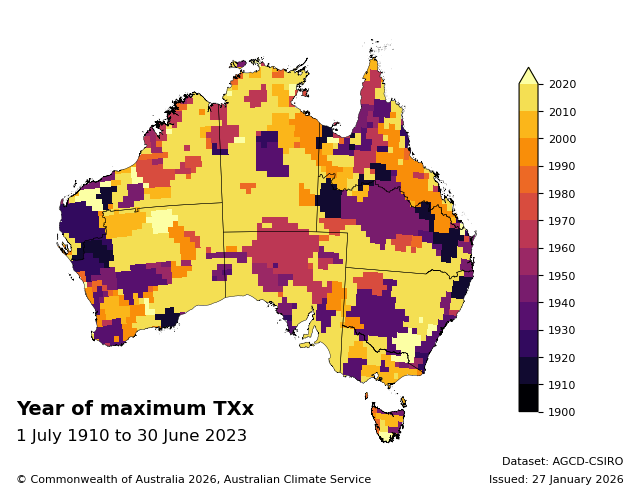

In [13]:
spatial_plots.plot_event_year(info, obs_ds, time_agg, ticks=np.arange(1900, 2025, 10))

## Most common month of event

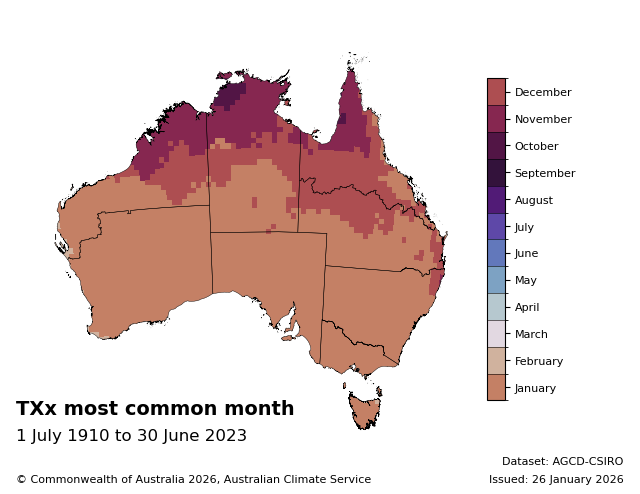

In [57]:
spatial_plots.plot_event_month_mode(info, obs_ds)

([<matplotlib.axis.XTick at 0x150c1e40e010>,
 [Text(1, 0, 'Jan'),
  Text(2, 0, 'Feb'),
  Text(3, 0, 'Mar'),
  Text(4, 0, 'Apr'),
  Text(5, 0, 'May'),
  Text(6, 0, 'Jun'),
  Text(7, 0, 'Jul'),
  Text(8, 0, 'Aug'),
  Text(9, 0, 'Sep'),
  Text(10, 0, 'Oct'),
  Text(11, 0, 'Nov'),
  Text(12, 0, 'Dec')])

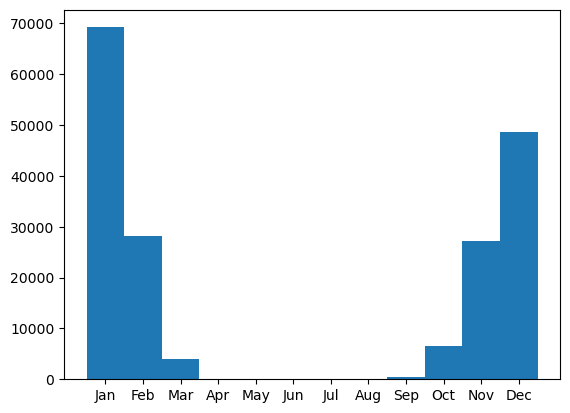

In [13]:
# Event month distribution (based on all grid points)
months = obs_ds.event_time.dt.month
months = xr.where(~np.isnan(obs_ds[var]), months, np.nan)
months.plot.hist(bins=np.arange(0.5, 13))
plt.xticks(np.arange(1, 13), [calendar.month_abbr[i] for i in range(1, 13)])


## Map of metric median

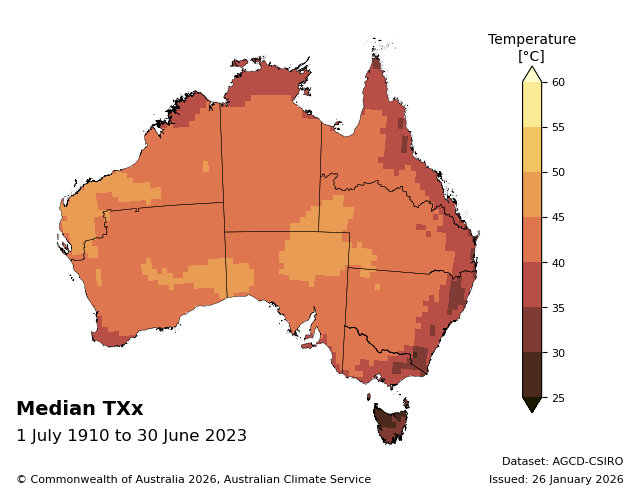

In [67]:
spatial_plots.plot_time_agg(info, obs_ds, "median")

# Map of metric maximum/minimum

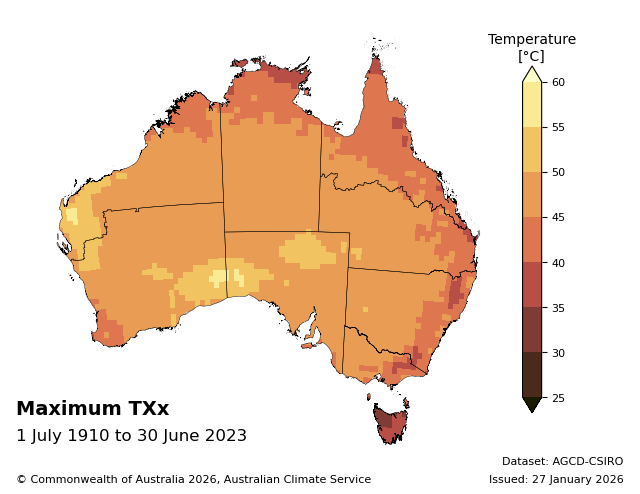

In [14]:
spatial_plots.plot_time_agg(info, obs_ds, time_agg)

# GEV analysis

In [24]:
# Load GEV parameters
covariate = obs_ds[time_dim].dt.year
times = xr.DataArray(gev_trend_period, dims="time")

In [ ]:
# # --nonstationary --covariate time.year --fitstart LMM --use_basinhopping --file_kwargs variables=tasmax shapefile=/g/data/xv83/unseen-projects/outputs/txx/shapefiles/australia_buffered_2deg.shp shape_overlap=0.1 --reference_time_period 1961-06-30 2023-06-30
# ds = fileio.open_dataset(
#     obs_file,
#     variables="tasmax",
#     shapefile="/g/data/xv83/unseen-projects/outputs/txx/shapefiles/australia_buffered_2deg.shp",
#     shape_overlap=0.1,
# )
# covariate = ds[time_dim].dt.year
# times = xr.DataArray(gev_trend_period, dims="time")
# ds_params_ns = eva.fit_gev(
#     ds[var],
#     core_dim=time_dim,
#     covariate=covariate,
#     stationary=False,
#     fitstart="scipy_fitstart",
#     use_basinhopping=True,
# )
# dparams_ns = ds_params_ns

In [16]:
dparams_ns = fileio.open_dataset(
    gev_params_nonstationary_file, shapefile=shapefile, shape_overlap=shape_overlap
)
dparams_ns

<xarray.Dataset> Size: 5MB
Dimensions:    (lat: 66, lon: 82, dparams: 5, time: 113)
Coordinates:
  * lat        (lat) float64 528B -43.5 -43.0 -42.5 -42.0 ... -12.0 -11.5 -11.0
  * lon        (lon) float64 656B 113.0 113.5 114.0 114.5 ... 152.5 153.0 153.5
  * dparams    (dparams) <U10 200B 'c' 'location_0' ... 'scale_0' 'scale_1'
  * time       (time) object 904B 1911-06-30 00:00:00 ... 2023-06-30 00:00:00
Data variables:
    tasmax     (lat, lon, dparams) float64 216kB dask.array<chunksize=(66, 82, 5), meta=np.ndarray>
    covariate  (time, lat, lon) float64 5MB dask.array<chunksize=(113, 66, 82), meta=np.ndarray>
Attributes: (12/34)
    CDI:                           Climate Data Interface version ?? (http://...
    history:                       Tue Jan 27 10:01:29 2026: /g/data/xv83/as3...
    institution:                   Australian Bureau of Meteorology, GPO Box ...
    Conventions:                   CF-1.6
    geospatial_lat_min:            -44.525
    geospatial_lat_max:            -9.975
    ...                            ...
    licence:                       Copyright for any data supplied by the Bur...
    id:                            Australian Gridded Climate Data (AGCD)
    summary:                       The daily maximum temperature station data...
    naming_authority:              au.gov.bom
    CDO:                           Climate Data Operators version 1.7.0 (http...
    regrid_method:                 conservative

In [17]:
dparams_ns = dparams_ns[var]

# GEV parameters
### Non-stationary GEV parameters

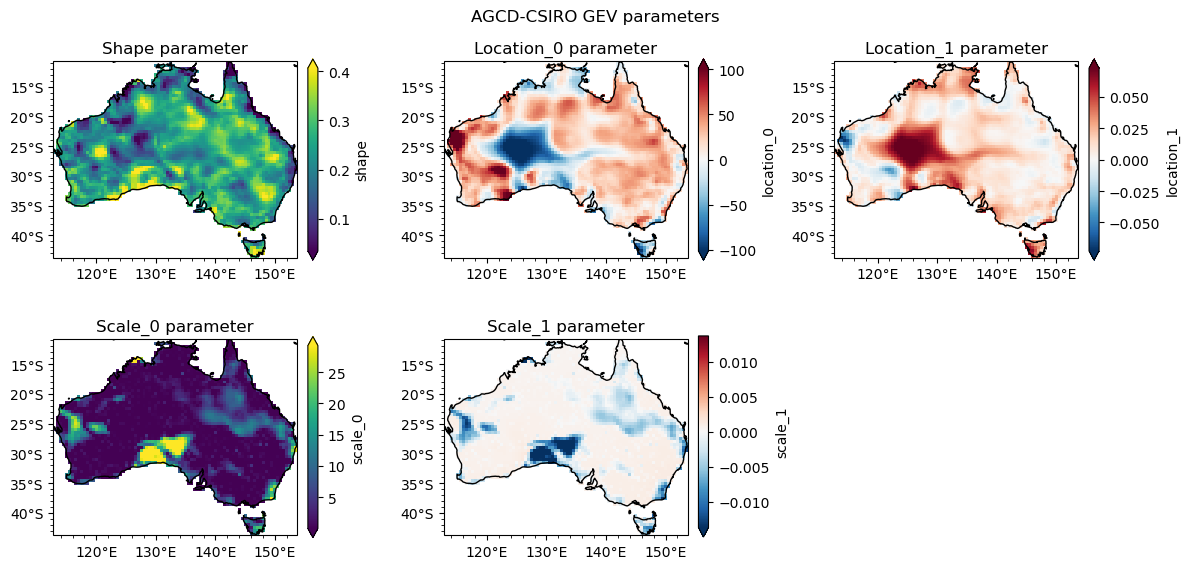

In [18]:
eva.spatial_plot_gev_parameters(
    dparams_ns,
    dataset_name=obs_name,
    outfile=f"{info.fig_dir}/gev_parameters_{info.filestem()}.png",
)

### Plot GEV trend parameters

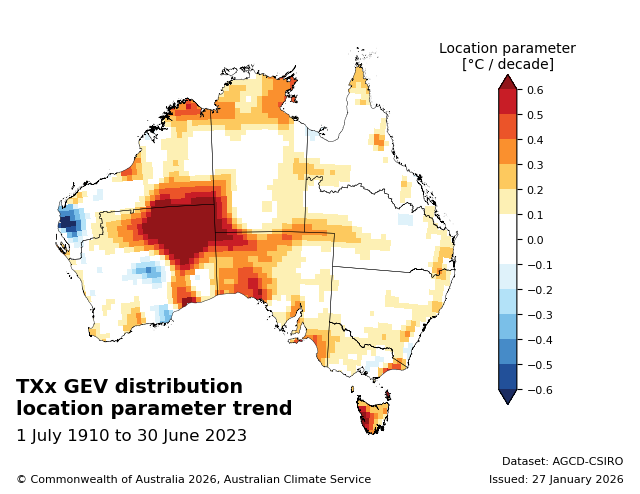

In [22]:
spatial_plots.plot_gev_param_trend(info, dparams_ns, "location")

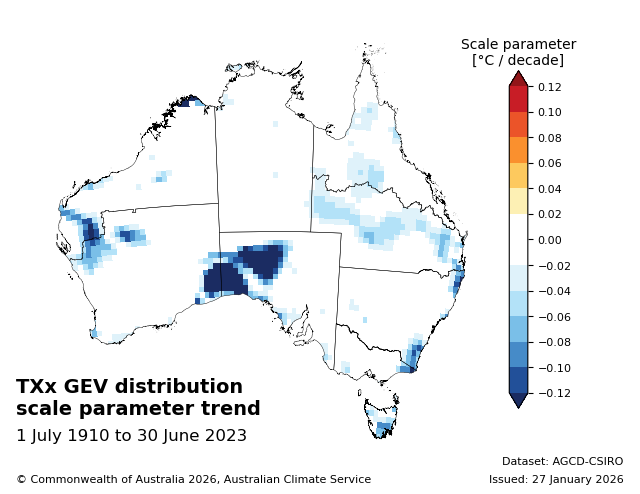

In [21]:
spatial_plots.plot_gev_param_trend(info, dparams_ns, "scale")

## Annual reccurence of observed max/min event

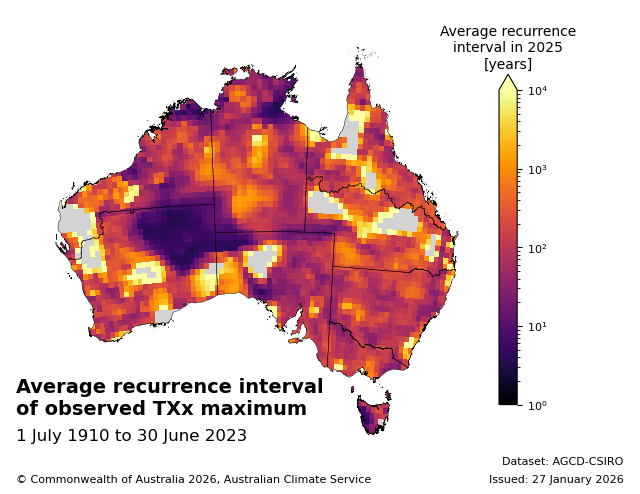

In [20]:
spatial_plots.plot_obs_ari(
    info,
    obs_ds,
    None,
    dparams_ns,
    covariate_base,
    time_agg=time_agg,
)

## Annual exceedance probability 
### GEV-based exceedance probability

In [26]:
# ARI: 10, 100, 1000 years (i.e., 10% AEP is equiv to a 1-in-10-year event)
aep = 1

### Plot of 1% AEP (1-in-100-year event) using the non-stationary GEV (past year, current year and the change per decade)

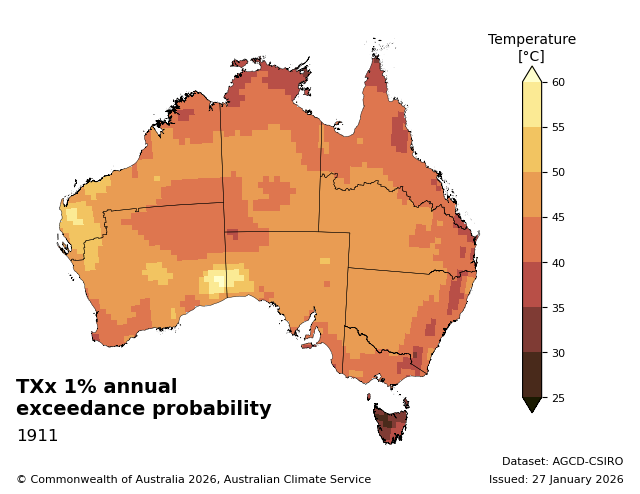

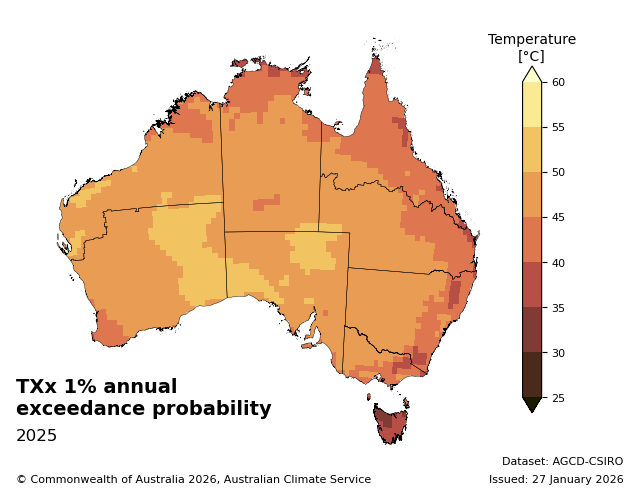

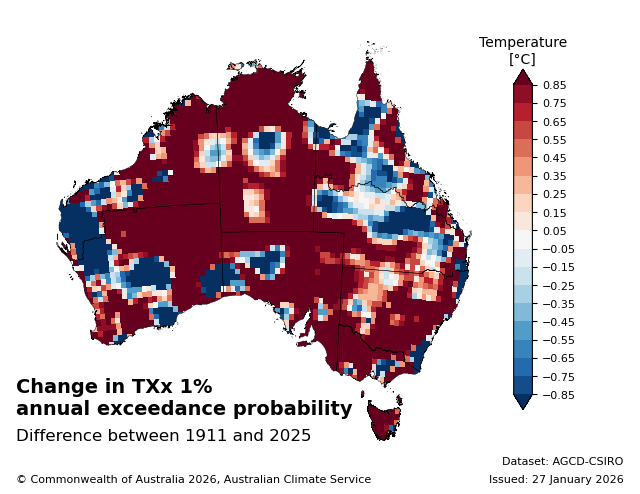

In [27]:
spatial_plots.plot_aep(
    info,
    dparams_ns,
    times,
    aep=aep,
)

## Probability of breaking the observed record

In [ ]:
from spatial_plots import *
import cmocean
from acs_plotting_maps import plot_acs_hazard, tick_dict

start_year = 2025
n_years = 10
mask = None

# Get the event record (return period) for the obs data
record = ds[info.var].reduce(spatial_plots.func_dict[time_agg], dim="time")
cumulative_probability = spatial_plots.nonstationary_new_record_probability(
    record, dparams_ns, start_year, n_years, info.time_dim
)

baseline = (
    f"{obs_ds.time.dt.year.min().item() - 1} to {obs_ds.time.dt.year.max().item()}"
)
fig, ax = plot_acs_hazard(
    data=cumulative_probability * 100,
    stippling=mask,
    title=f"Probability of record breaking\n{info.metric} in the next {n_years} years",
    date_range=f"{start_year} to {start_year + n_years}",
    baseline=baseline,
    cmap=cmocean.cm.thermal,
    cbar_extend="neither",
    ticks=tick_dict["percent"],
    cbar_label="Probability [%]",
    dataset_name=info.long_name_with_obs,
    outfile=f"{info.fig_dir}/new_record_probability_{n_years}-year_{info.filestem(mask)}.png",
    **info.acs_map_plot_kwargs,
)

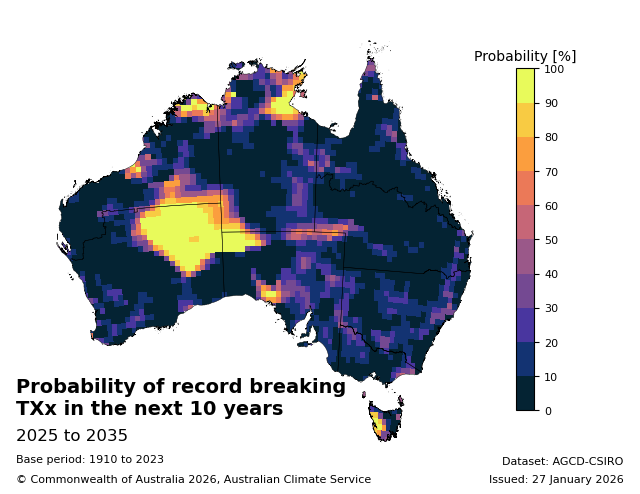

In [28]:
spatial_plots.plot_new_record_probability(
    info,
    obs_ds,
    None,
    dparams_ns,
    covariate_base,
    time_agg,
    n_years=10,
)

/g/data/xv83/as3189/conda/envs/unseen/lib/python3.11/site-packages/xarray/namedarray/core.py:919: RuntimeWarning: All-NaN slice encountered
  data = func(self.data, axis=axis, **kwargs)


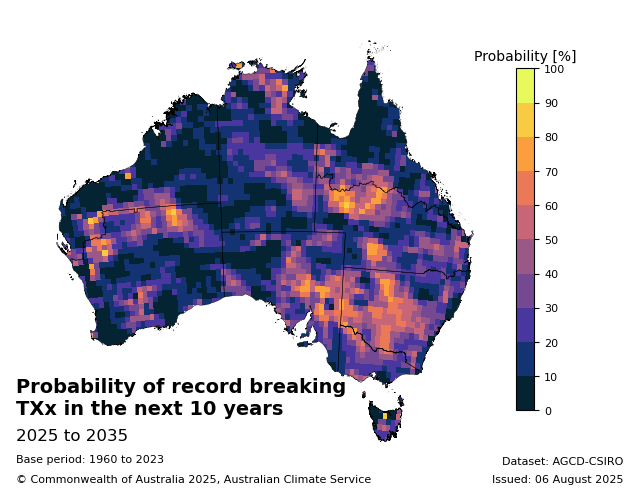

In [29]:
# Repeat for max event removed
info_copy = info.__copy__()  # Copy InfoSet object & update names
info_copy.long_name = f"{info.long_name} (max event removed)"
info_copy.file = info_copy.file.with_name(f"{info.filestem()}_drop_max.nc")

spatial_plots.plot_new_record_probability(
    info_copy,
    obs_ds,
    None,
    dparams_ns,
    covariate_base,
    time_agg,
    n_years=10,
)